In [1]:
import pandas as pd
import numpy as np

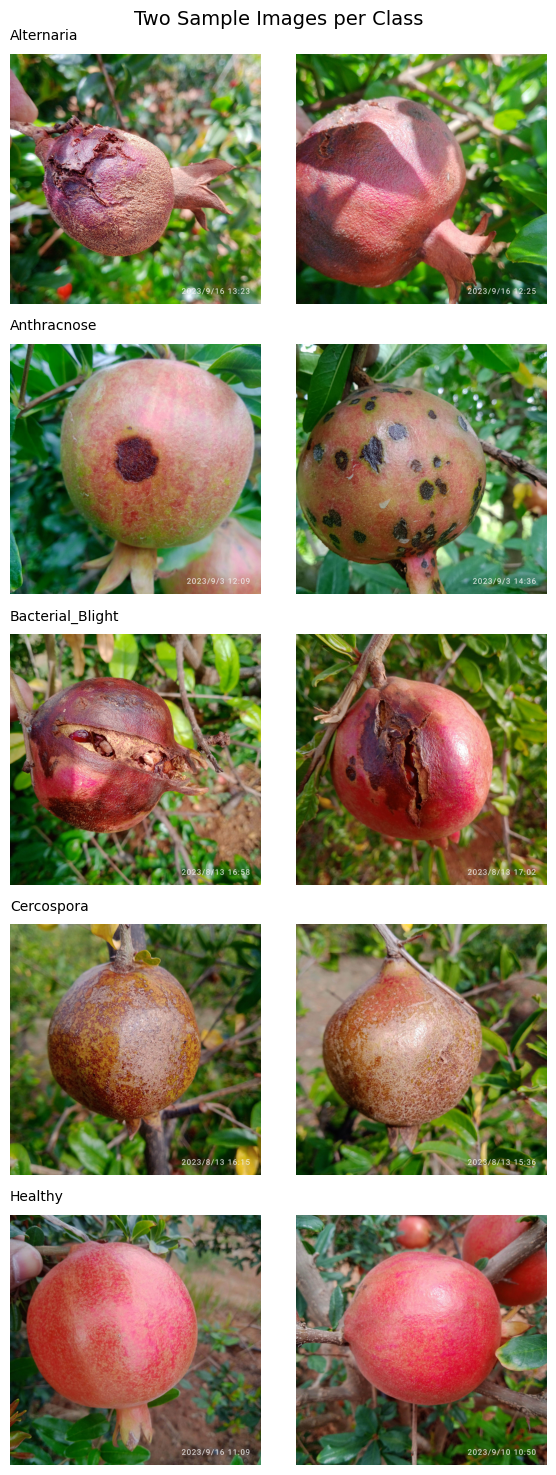

In [9]:
import os
import cv2
import matplotlib.pyplot as plt

# ============================
# 1. DATASET PATH
# ============================

dataset_path = "/home/ravjot/datasets/Pomegranate Diseases Dataset"

classes = sorted(os.listdir(dataset_path))

# ============================
# 2. CREATE SUBPLOTS
# ============================

num_classes = len(classes)

fig, axes = plt.subplots(num_classes, 2, figsize=(6, 3 * num_classes))

# ============================
# 3. LOOP THROUGH CLASSES
# ============================

for row, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(class_path):
        continue

    img_list = os.listdir(class_path)

    if len(img_list) < 2:
        continue

    # Take first 2 images
    for col in range(2):
        img_path = os.path.join(class_path, img_list[col])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[row, col]
        ax.imshow(img)
        ax.axis("off")

        # Add border (BOX EFFECT)
        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(2)

    # Add class label on left side (BOX TITLE)
    axes[row, 0].set_title(cls, fontsize=10, loc="left", pad=10)

# ============================
# 4. FINAL TOUCH
# ============================

plt.suptitle("Two Sample Images per Class", fontsize=14)

plt.tight_layout()

# Save for paper
plt.savefig("boxed_samples.png", dpi=300)

plt.show()

In [4]:
import os

# ============================
# 1. DATASET PATH
# ============================

dataset_path = "/home/ravjot/datasets/Pomegranate Diseases Dataset"

# ============================
# 2. ANALYZE DATASET
# ============================

class_counts = {}
total_images = 0

classes = sorted(os.listdir(dataset_path))

print("\n📊 Dataset Summary\n")

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(class_path):
        continue

    num_images = len(os.listdir(class_path))
    class_counts[cls] = num_images
    total_images += num_images

    print(f"{cls}: {num_images} images")

print("\n----------------------------")
print(f"Total Images: {total_images}")
print(f"Total Classes: {len(class_counts)}")

# ============================
# 3. CLASS DISTRIBUTION (%)
# ============================

print("\n📈 Class Distribution (%)\n")

for cls, count in class_counts.items():
    percentage = (count / total_images) * 100
    print(f"{cls}: {percentage:.2f}%")

# ============================
# 4. TRAIN / VALIDATION SPLIT
# ============================

train_split = 0.8

train_images = int(total_images * train_split)
val_images = total_images - train_images

print("\n📂 Data Split (Approx):")
print(f"Training Images: {train_images}")
print(f"Validation Images: {val_images}")


📊 Dataset Summary

Alternaria: 886 images
Anthracnose: 1166 images
Bacterial_Blight: 966 images
Cercospora: 631 images
Healthy: 1450 images

----------------------------
Total Images: 5099
Total Classes: 5

📈 Class Distribution (%)

Alternaria: 17.38%
Anthracnose: 22.87%
Bacterial_Blight: 18.94%
Cercospora: 12.37%
Healthy: 28.44%

📂 Data Split (Approx):
Training Images: 4079
Validation Images: 1020
